In [3]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ! pip install pandas
# ! pip install numpy
# ! pip install seaborn
# ! pip matplotlib.pyplot  


In [4]:
import pandas as pd


# IMPORTANT: Replace 'your_input_file.txt' with the actual path to your .txt file.
txt_file_path = 'D:\Studies of Data Science\predictive maintance\project_02\sensor.txt'

# IMPORTANT: Replace 'your_output_file.csv' with the desired path for your .csv file.
csv_file_path = 'D:\Studies of Data Science\predictive maintance\project_02\sensor.csv'

# Set the delimiter for your .txt file. Common delimiters:
# ',', '\t' (for tab), '\s+' (for one or more spaces), ';' (for semicolon)
# If your .txt file has no specific separator (e.g., fixed-width columns), 
# you might need to use `pd.read_fwf` instead of `pd.read_csv`.
delimiter = ','

# --- Conversion logic ---
try:
    # Read the .txt file into a pandas DataFrame
    df = pd.read_csv(txt_file_path, sep=delimiter)
    
    # Write the DataFrame to a .csv file
    df.to_csv(csv_file_path, index=False)
    
    print(f"Successfully converted '{txt_file_path}' to '{csv_file_path}'")
    print("First 5 rows of the converted CSV data:")
    display(df.head())
    
except FileNotFoundError:
    print(f"Error: The file '{txt_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred during conversion: {e}")

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
C:\Users\hp\AppData\Local\Temp\ipykernel_5932\1356934558.py:5: SyntaxWarning: invalid escape sequence '\S'
  txt_file_path = 'D:\Studies of Data Science\predictive maintance\project_02\sensor.txt'
C:\Users\hp\AppData\Local\Temp\ipykernel_5932\1356934558.py:8: SyntaxWarning: invalid escape sequence '\S'
  csv_file_path = 'D:\Studies of Data Science\predictive maintance\project_02\sensor.csv'


Successfully converted 'D:\Studies of Data Science\predictive maintance\project_02\sensor.txt' to 'D:\Studies of Data Science\predictive maintance\project_02\sensor.csv'
First 5 rows of the converted CSV data:


,ID,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,machine_status,timestamp
0,1,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0,01-04-18 0:00
1,2,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0,01-04-18 0:01
2,3,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,0,01-04-18 0:02
3,4,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,0,01-04-18 0:03
4,5,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,0,01-04-18 0:04


In [6]:
sensor_data = pd.read_csv('sensor.csv')
sensor_data.head()

,ID,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,machine_status,timestamp
0,1,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0,01-04-18 0:00
1,2,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0,01-04-18 0:01
2,3,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,0,01-04-18 0:02
3,4,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,0,01-04-18 0:03
4,5,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,0,01-04-18 0:04


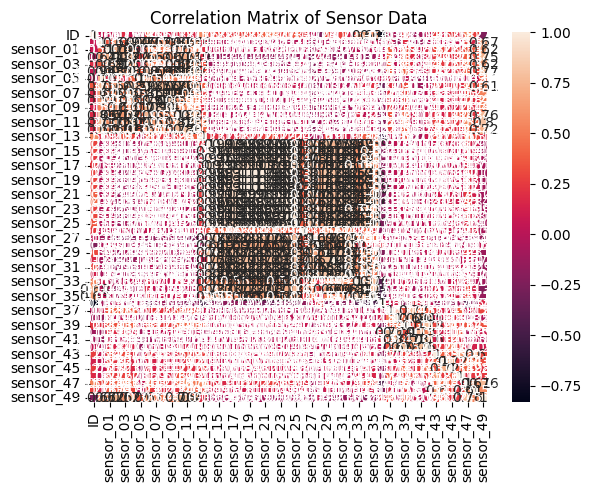

In [7]:
corr_matrix = sensor_data.iloc[:, 0:51].corr()

sns.heatmap(corr_matrix, annot=True)
plt.rcParams['figure.figsize'] = [15, 15]
plt.title('Correlation Matrix of Sensor Data')
plt.show()

In [8]:
counter = 0
for i in range(0, 51):
    for j in range(i + 1, 51):
        if((corr_matrix.iloc[i, j] > 0.7) | (corr_matrix.iloc[i, j] < -0.7)):
            print(counter , i, j, corr_matrix.iloc[i, j])
            counter = counter + 1
            

0 0 37 -0.8291001542058636
1 1 5 0.9428999055250306
2 1 6 0.7566563857417025
3 1 7 0.7507366009055012
4 1 11 0.8614480538551018
5 1 12 0.7707212978326299
6 2 3 0.7374064455579192
7 3 4 0.8223386790391445
8 3 5 0.8203922430541137
9 3 11 0.7565898212621941
10 3 12 0.7113326110198461
11 3 50 0.7490863253372084
12 5 7 0.8038762796092045
13 5 11 0.9075540328705785
14 5 12 0.862637161130918
15 5 13 0.8031656382863029
16 5 50 0.7738396713474919
17 7 8 0.8530357884776147
18 7 9 0.7640213710291174
19 7 10 0.7750287392354733
20 7 11 0.7609655848777878
21 7 12 0.7547649167138246
22 8 9 0.9067178677096641
23 8 10 0.9028351433443043
24 9 10 0.8448857330079766
25 11 12 0.8258940911552941
26 11 13 0.7663216331772968
27 11 50 0.7606816178775552
28 12 13 0.8317067001508044
29 12 50 0.8005653676570874
30 13 50 0.7247684727401991
31 15 16 0.9903591662548819
32 15 17 0.9301880155564075
33 15 18 0.9011021448087404
34 15 19 0.983040304147985
35 15 20 0.9799840382673692
36 15 21 0.9717043612300369
37 15 22 0

In [9]:
normal_data = sensor_data.loc[sensor_data["machine_status"]=="NORMAL"]
broken_data = sensor_data.loc[sensor_data["machine_status"]=="BROKEN"]
recovering_data = sensor_data.loc[sensor_data["machine_status"]=="RECOVERING"]
#print(Normal_data)
print(len(normal_data), len(recovering_data), len(broken_data))

0 0 0


In [10]:
mean_df = pd.DataFrame(np.zeros((51,4))) # add min and max and distribution plots and try after normalizing data
mean_df.columns = ("Overall","NORMAL","RECOVERING","BROKEN")
for i in range(0,51):
    mean_df.iloc[i,0] = sensor_data.iloc[:,i].mean()
    mean_df.iloc[i,1] = normal_data.iloc[:,i].mean()
    mean_df.iloc[i,2] = recovering_data.iloc[:,i].mean()
    mean_df.iloc[i,3] = broken_data.iloc[:,i].mean()              

In [17]:
# median_df = pd.DataFrame(np.zeros((51,4)))
# median_df.columns = ("Overall","NORMAL","RECOVERING","BROKEN")
# for i in range(0,51):
#     median_df.iloc[i,0] = sensor_data.iloc[:,i].describe()[5]
#     median_df.iloc[i,1] = normal_data.iloc[:,i].describe()[5]
#     median_df.iloc[i,2] = recovering_data.iloc[:,i].describe()[5]
#     median_df.iloc[i,3] = broken_data.iloc[:,i].describe()[5]
# ...existing code...
median_df = pd.DataFrame(np.zeros((51,4)))
median_df.columns = ("Overall","NORMAL","RECOVERING","BROKEN")
for i in range(0,51):
    median_df.iloc[i,0] = sensor_data.iloc[:,i].median()
    median_df.iloc[i,1] = normal_data.iloc[:,i].median()
    median_df.iloc[i,2] = recovering_data.iloc[:,i].median()
    median_df.iloc[i,3] = broken_data.iloc[:,i].median()
# ...existing code...